# MODUL 2 <br>
**Nama : M. Alfatih** <br>
**NIM : F1D02410013** <br>
**KLP : 1**

# Import Library

In [121]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Code di atas digunakan untuk mengimpor tiga library yaitu matplotlib.pyplot, numpy, dan cv2 (yang merupakan alias untuk library OpenCV). matplotlib.pyplot digunakan untuk membuat visualisasi grafik, plot, dan grafik lainnya di Python. Dalam kode ini, kita akan menggunakan pyplot untuk membuat plot gambar. numpy adalah library Python yang digunakan untuk bekerja dengan array dan matriks. cv2 adalah library OpenCV (Open Source Computer Vision Library) yang digunakan untuk memproses gambar.

# TAHAP PENAMPILAN GAMBAR

Tahap awal kode dibawah ini membaca citra menggunakan plt.imread() agar langsung berada dalam format RGB, sehingga tidak perlu konversi warna. Citra ditampilkan murni tanpa perubahan intensitas piksel, mempertahankan sebaran gelap-terang bawaan aslinya.

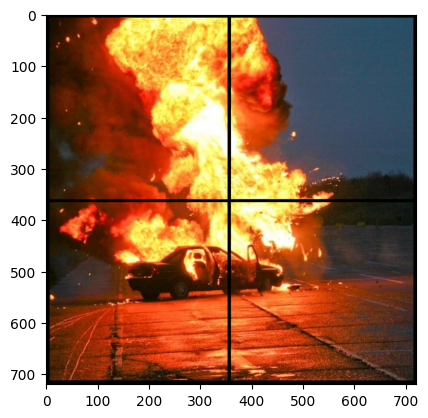

In [122]:
citra1 = plt.imread("Assets/Meledak.png")
plt.imshow(citra1)

# TAHAP Pemotongan

Kode dibawah ini melakukan operasi cropping untuk membagi citra menjadi empat kuadran menggunakan teknik pemotongan (slicing) matriks NumPy. Pendekatan ini dipilih karena sangat efisien dalam memanipulasi koordinat batas gambar secara langsung dengan acuan titik tengah dan ukuran margin yang ditentukan. Pada proses ini tidak ada perubahan nilai intensitas piksel, melainkan hanya pengurangan dimensi spasialnya saja

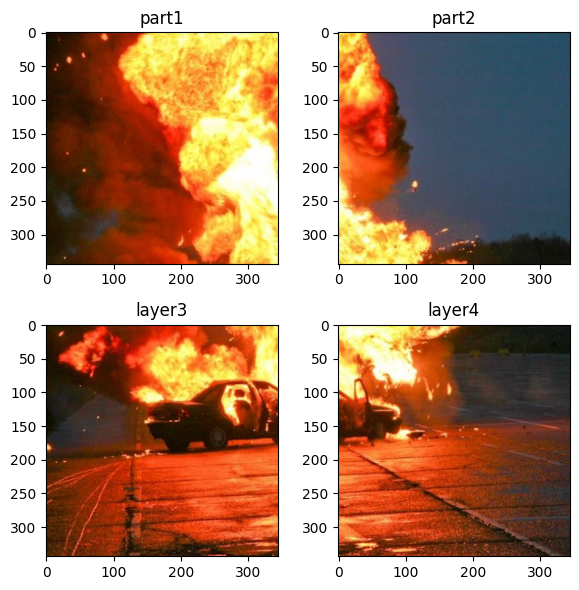

In [123]:
img_rgb = cv2.imread("Assets/Meledak.png")
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

tinggi, lebar, _ = img_rgb.shape
tengah_y = tinggi // 2
tengah_x = lebar // 2

margin = 8 

part1 = img_rgb[margin : tengah_y - margin, margin : tengah_x - margin]
part2 = img_rgb[margin : tengah_y - margin, tengah_x + margin : lebar - margin]
part3 = img_rgb[tengah_y + margin : tinggi - margin, margin : tengah_x - margin]
part4 = img_rgb[tengah_y + margin : tinggi - margin, tengah_x + margin : lebar - margin]

plt.figure(figsize=(6, 6))

plt.subplot(2, 2, 1)
plt.imshow(part1)
plt.title("part1")

plt.subplot(2, 2, 2)
plt.imshow(part2)
plt.title("part2")

plt.subplot(2, 2, 3)
plt.imshow(part3)
plt.title("layer3")

plt.subplot(2, 2, 4)
plt.imshow(part4)
plt.title("layer4")
plt.tight_layout()
plt.show()

Hasil visualisasi di atas mengonfirmasi keberhasilan pembagian citra menjadi empat kuadran secara presisi menggunakan operasi slicing matriks. Penggunaan parameter margin sebesar 8 piksel menciptakan batas pemisah di antara potongan-potongan tersebut, sehingga setiap bagian terpotong dengan baik

# Tahap Merge

Fungsi merge_image dirancang untuk menggabungkan kembali potongan citra secara manual menggunakan manipulasi koordinat matriks NumPy dan inisialisasi kanvas kosong (np.zeros). Pada proses penyusunan horizontal dan vertikal ini, sama sekali tidak ada modifikasi pada nilai intensitas warna. Pemindahan piksel ke koordinat baru dilakukan secara murni, sehingga mendistribusikan ulang komposisi visual gambar menjadi utuh kembali tanpa menggeser tingkat kecerahan maupun kontras bawaannya.

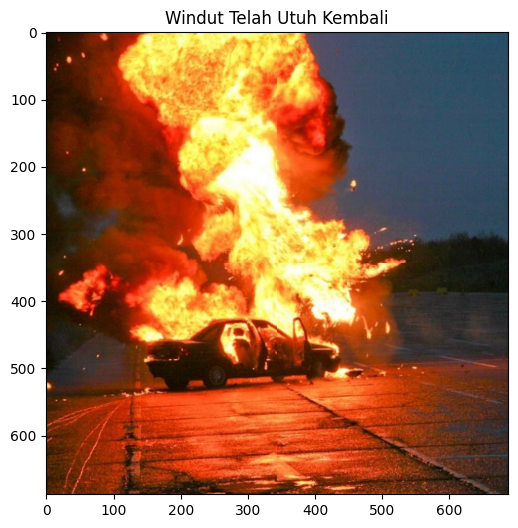

In [124]:
def merge_image(citra1, citra2, orientation='H'):
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]
        
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype)
            
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2
        
    else:
        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])
        
        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)
            
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2
        
    return gabungan

atas = merge_image(part1, part2, orientation='H')

bawah = merge_image(part3, part4, orientation='H')

citra_utuh = merge_image(atas, bawah, orientation='V')

plt.figure(figsize=(6, 6))
plt.imshow(citra_utuh)
plt.title('Windut Telah Utuh Kembali')
plt.axis('on')
plt.show()

Hasil visualisasi di atas membuktikan bahwa rekonstruksi spasial dari keempat potongan kuadran berhasil dilakukan secara sempurna tanpa meninggalkan celah atau distorsi visual. Distribusi intensitas dan susunan piksel RGB kembali utuh seperti citra aslinya karena proses penggabungan murni memindahkan data matriks berdasarkan pemetaan koordinat,

# TAHAP Grayscale

Kode dibawah ini adalah penggunaan cv2.cvtColor mengubah citra RGB menjadi grayscale untuk menyederhanakan matriks dari 3 saluran menjadi 1 saluran warna. Operasi ini mereduksi informasi warna menjadi nilai intensitas kecerahan tunggal (0-255). Penambahan parameter cmap='gray' wajib dilakukan agar Matplotlib memetakan matriks 2D tersebut menggunakan spektrum abu-abu yang benar.

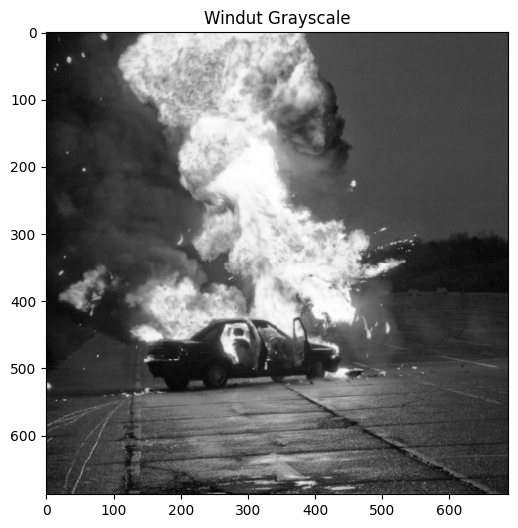

In [125]:
citra_gray = cv2.cvtColor(citra_utuh, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(citra_gray, cmap='gray')
plt.title('Windut Grayscale')
plt.axis('on') 
plt.show()

Hasil visualisasi di atas mengonfirmasi keberhasilan konversi citra menjadi grayscale. Distribusi piksel kini murni merepresentasikan tingkat kecerahan tanpa informasi warna. Area pusat ledakan dipetakan menjadi kelompok piksel berintensitas sangat tinggi (putih/terang), sedangkan area sekitar seperti asap dan mobil menjadi piksel berintensitas rendah (gelap).

# TAHAP Ekualisasi

Kode dibawah ini adalah ekualisasi yang mengimplementasikan algoritma pemerataan histogram secara manual melalui perhitungan Cumulative Distribution Function (CDF). Pendekatan perulangan ini dipilih untuk membedah proses matematis di balik pemetaan ulang intensitas piksel, alih-alih menggunakan fungsi instan bawaan pustaka. Proses ini mengubah distribusi piksel yang semula menumpuk di rentang tertentu menjadi lebih merata di seluruh spektrum keabuan (0-255). Pemetaan nilai piksel baru berdasarkan CDF yang dinormalisasi ini secara efektif memperlebar rentang dinamis citra, sehingga kontras gambar meningkat secara keseluruhan. Visualisasi gabungan histogram memfasilitasi analisis komparatif langsung terhadap pergeseran frekuensi intensitas sebelum (hijau) dan sesudah (merah) ekualisasi.

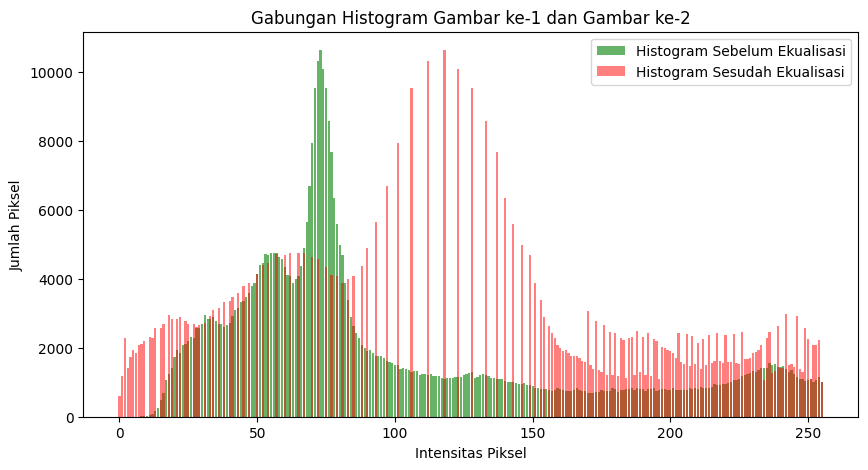

In [126]:
def ekualisasi(citra):
    height, width = citra.shape
    
    hist = np.zeros(256, dtype=int)
    
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1
            
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    hasil = np.zeros_like(citra, dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]
            
    return hasil

citra_eq = ekualisasi(citra_gray)

def hitung_histogram(citra):
    hist = np.zeros(256, dtype=int)
    tinggi, lebar = citra.shape
    for i in range(tinggi):
        for j in range(lebar):
            hist[citra[i, j]] += 1
    return hist

hist_sebelum = hitung_histogram(citra_gray)
hist_sesudah = hitung_histogram(citra_eq)

plt.figure(figsize=(10, 5))

plt.bar(range(256), hist_sebelum, color='green', alpha=0.6, label='Histogram Sebelum Ekualisasi')
plt.bar(range(256), hist_sesudah, color='red', alpha=0.5, label='Histogram Sesudah Ekualisasi')

plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend()
plt.show()

Grafik di atas memvisualisasikan dampak langsung dari operasi ekualisasi histogram terhadap distribusi piksel citra. Pada histogram awal (hijau), terlihat akumulasi frekuensi piksel yang sangat dominan menumpuk pada rentang intensitas rendah hingga menengah (sekitar nilai 50-80), mengindikasikan bahwa citra memiliki kontras yang kurang optimal. Setelah ekualisasi (merah), terlihat jelas bahwa algoritma berbasis CDF berhasil mendistribusikan ulang nilai-nilai piksel tersebut agar meregang dan menyebar lebih merata melintasi seluruh spektrum keabuan (0-255).

# TAHAP Spesifikasi

Fungsi spesifikasi_histogram dibawah ini mengimplementasikan teknik histogram matching untuk mengubah distribusi intensitas citra asal agar menyerupai karakteristik citra target. Secara teknis, algoritma bekerja dengan memetakan nilai CDF (Cumulative Distribution Function) dari citra asal ke nilai intensitas terdekat pada CDF citra target menggunakan pencarian selisih minimum. Pendekatan manual ini dipilih untuk menunjukkan mekanisme transformasi non-linear yang lebih spesifik dibandingkan ekualisasi biasa, karena hasil akhir tidak hanya sekadar merata, melainkan mengikuti pola gelap-terang (kontras) dari referensi citra bunga.

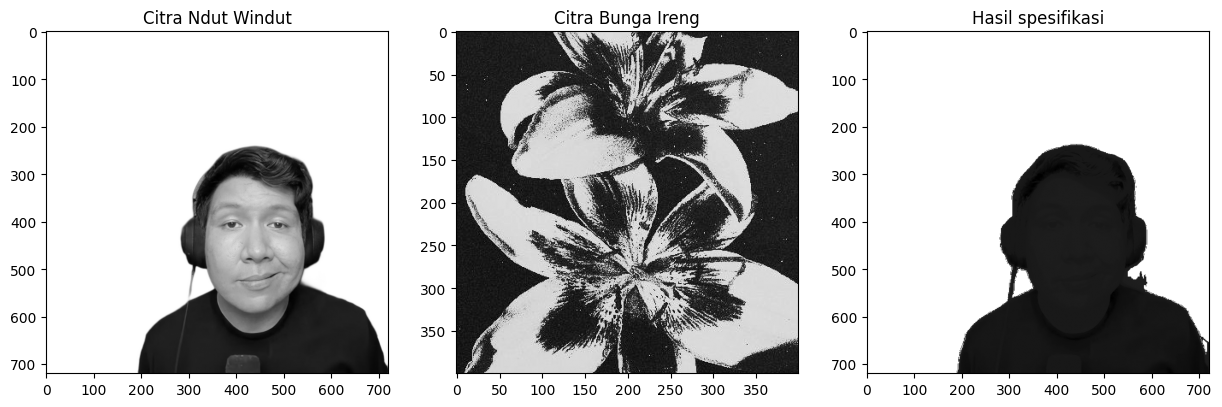

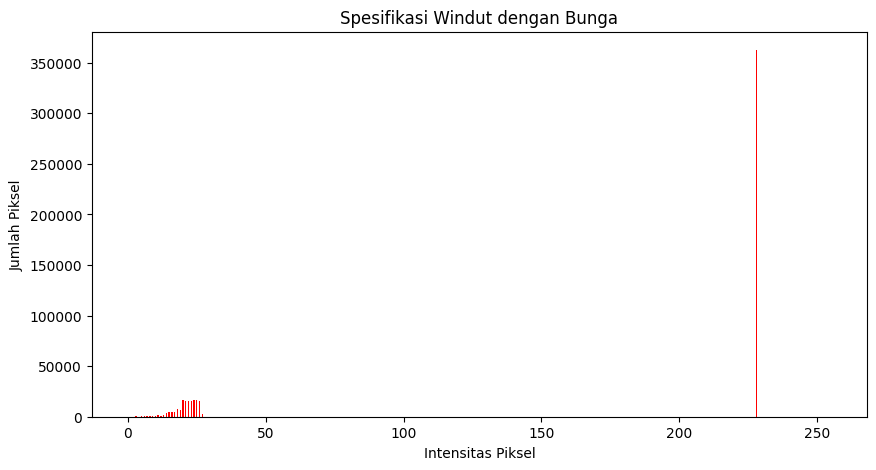

In [127]:
citra_asal = cv2.imread('Assets/Windut.png', cv2.IMREAD_GRAYSCALE) 
citra_target = cv2.imread('Assets/Bunga.png', cv2.IMREAD_GRAYSCALE)

def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    height_a, width_a = citra_asal.shape
    for i in range(height_a):
        for j in range(width_a):
            hist_asal[citra_asal[i, j]] += 1

    height_t, width_t = citra_target.shape
    for i in range(height_t):
        for j in range(width_t):
            hist_target[citra_target[i, j]] += 1
            
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
        
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    
    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(selisih)
        
    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]
            
    return hasil

spesifikasi1 = spesifikasi_histogram(citra_asal, citra_target)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(citra_asal, cmap='gray'); plt.title("Citra Ndut Windut"); plt.axis('on')
plt.subplot(1, 3, 2); plt.imshow(citra_target, cmap='gray'); plt.title("Citra Bunga Ireng"); plt.axis('on')
plt.subplot(1, 3, 3); plt.imshow(spesifikasi1, cmap='gray'); plt.title("Hasil spesifikasi"); plt.axis('on')
plt.show()

hist_hasil = hitung_histogram(spesifikasi1)

plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_hasil, color='red', width=0.5)
plt.title('Spesifikasi Windut dengan Bunga')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.show()

Hasil visualisasi diatas menunjukkan efektivitas teknik histogram matching dalam mentransfer gaya tonal dari citra bunga ke objek utama. Melalui pemetaan CDF, citra hasil kini memiliki karakteristik kontras yang serupa dengan referensi, di mana bagian latar belakang menjadi sangat terang (mendekati putih) sementara objek utama menjadi jauh lebih gelap. Hal ini diperkuat oleh grafik histogram hasil yang menunjukkan penumpukan piksel pada intensitas sangat tinggi dan sangat rendah, mencerminkan distribusi biner yang ekstrem dari citra bunga.

# TAHAP Cropping

Tahap kode dibawah ini menerapkan teknik masking manual menggunakan metode thresholding untuk menggabungkan dua citra berbeda. Dengan membandingkan nilai piksel objek terhadap ambang batas 200, algoritma secara selektif mengganti area latar belakang yang terang dengan data dari citra ledakan, sementara area objek diubah menjadi hitam. Operasi perulangan ini berhasil menciptakan efek siluet yang presisi, menunjukkan penerapan konsep segmentasi citra untuk memisahkan objek dari latar belakang aslinya secara manual.

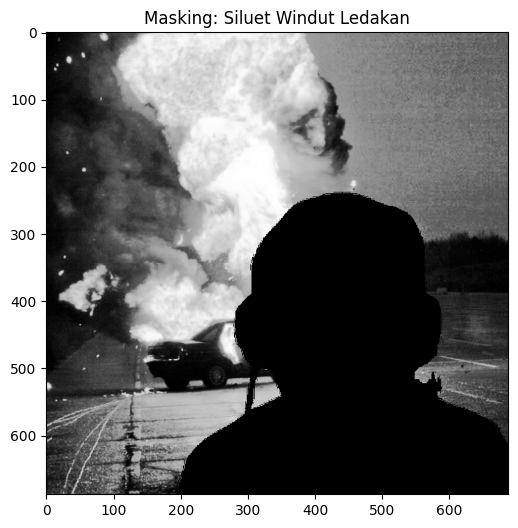

In [128]:
tinggi_bg, lebar_bg = citra_eq.shape 
tinggi_w, lebar_w = spesifikasi1.shape 

tinggi_min = min(tinggi_bg, tinggi_w)
lebar_min = min(lebar_bg, lebar_w)

bg_crop = np.zeros((tinggi_min, lebar_min), dtype=np.uint8)
windut_crop = np.zeros((tinggi_min, lebar_min), dtype=np.uint8)

for i in range(tinggi_min):
    for j in range(lebar_min):
        bg_crop[i, j] = citra_eq[i, j]
        windut_crop[i, j] = spesifikasi1[i, j]

citra_siluet = np.zeros((tinggi_min, lebar_min), dtype=np.uint8)

for i in range(tinggi_min):
    for j in range(lebar_min):
        if windut_crop[i, j] > 200:
            citra_siluet[i, j] = bg_crop[i, j]
        else:
            citra_siluet[i, j] = 0

plt.figure(figsize=(6, 6))
plt.imshow(citra_siluet, cmap='gray')
plt.title("Masking: Siluet Windut Ledakan")
plt.axis('on') 
plt.show()

Hasil visualisasi mengonfirmasi keberhasilan proses masking dalam memisahkan objek utama dari latar belakang aslinya. Penggunaan ambang batas intensitas pada citra hasil spesifikasi terbukti efektif untuk mengidentifikasi area latar belakang objek yang kemudian digantikan secara presisi oleh tekstur citra ledakan. Hasil akhirnya menunjukkan siluet objek yang tajam dengan latar belakang baru yang memiliki kontras tinggi

# TAHAP penggabungan citra dengan menempelkan objek utama ke background

Tahap dibawah ini melakukan penggabungan objek utama dengan latar belakang ledakan menggunakan teknik conditional masking berbasis ambang batas. Dengan menetapkan threshold pada nilai 230, algoritma secara otomatis mengganti area latar belakang objek yang terang dengan citra ledakan, namun tetap mempertahankan detail asli objek pada area yang lebih gelap. Operasi ini menghasilkan komposisi citra baru yang menyatukan dua sumber visual berbeda ke dalam satu dimensi spasial yang selaras melalui manipulasi nilai piksel secara manual.

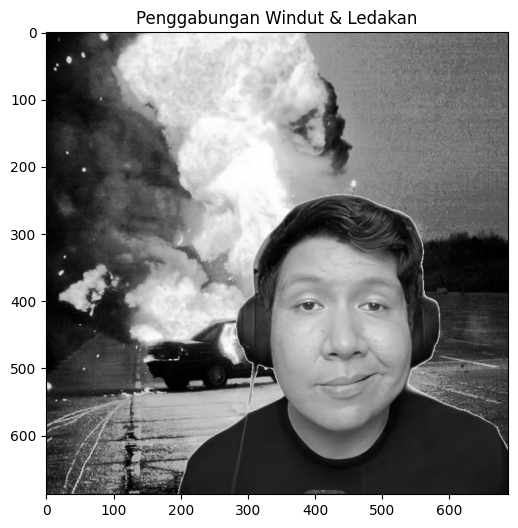

In [129]:
windut_asli_crop = np.zeros((tinggi_min, lebar_min), dtype=np.uint8)

for i in range(tinggi_min):
    for j in range(lebar_min):
        windut_asli_crop[i, j] = citra_asal[i, j]

hasil_gabungan = np.zeros((tinggi_min, lebar_min), dtype=np.uint8)

for i in range(tinggi_min):
    for j in range(lebar_min):
        if windut_asli_crop[i, j] > 230:
            hasil_gabungan[i, j] = bg_crop[i, j]
        else:
            hasil_gabungan[i, j] = windut_asli_crop[i, j]

plt.figure(figsize=(6, 6))
plt.imshow(hasil_gabungan, cmap='gray')
plt.title("Penggabungan Windut & Ledakan")
plt.axis('on') 
plt.show()

Hasil visualisasi ini menunjukkan keberhasilan integrasi antara objek utama dengan citra latar belakang melalui teknik thresholding yang lebih halus. Dengan menetapkan ambang batas pada nilai 230, sistem mampu membedakan area latar belakang putih dari citra asli secara efektif untuk kemudian digantikan dengan tekstur ledakan, sementara detail tekstur wajah dan pakaian tetap terjaga.

# Spesifikasi Penyempurnaan

Tahap dibawah ini menggunakan kembali fungsi spesifikasi_histogram untuk menyelaraskan distribusi intensitas citra hasil gabungan dengan citra langit sebagai referensi tonal baru. Proses ini bertujuan untuk mengharmonisasikan kontras dan pencahayaan pada seluruh bagian citra agar terlihat lebih menyatu mengikuti profil intensitas target. Hasil akhir menunjukkan pergeseran tonal yang signifikan pada objek maupun latar belakang, yang divalidasi oleh grafik histogram hasil yang kini memiliki pola distribusi serupa dengan citra langit.

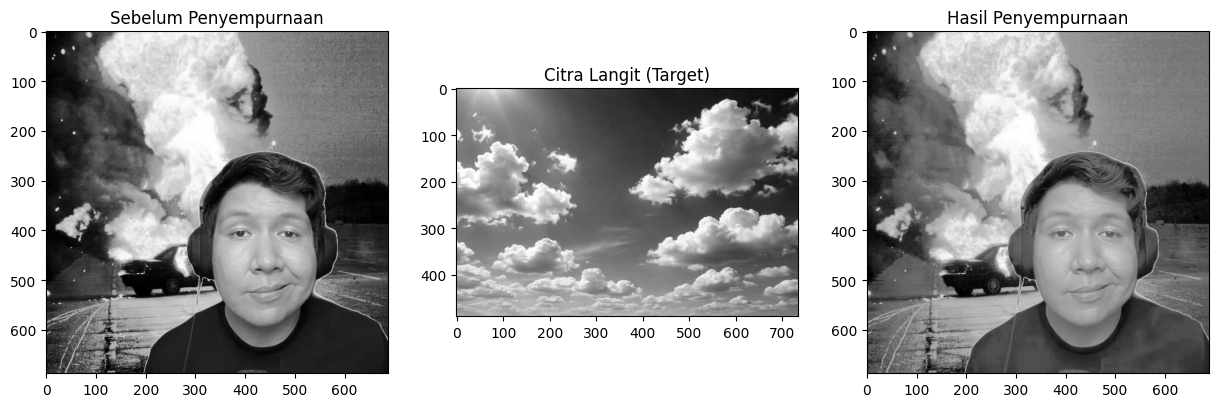

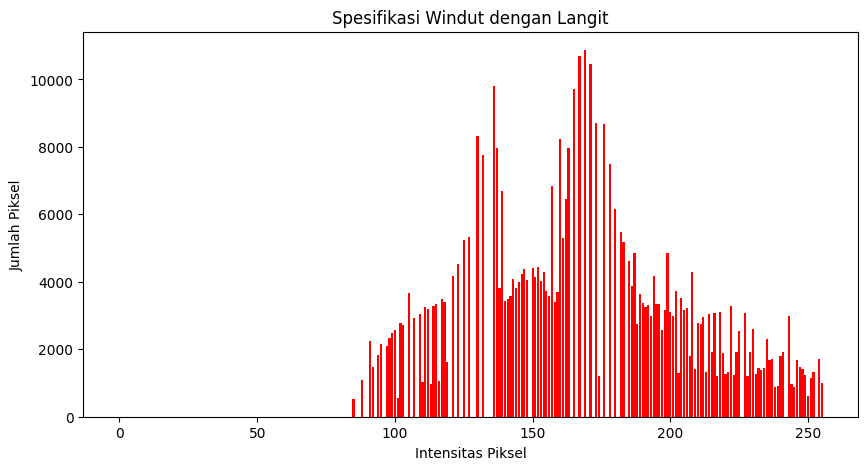

In [130]:
langit = cv2.imread('Assets/Langit.png')
langit_gray = cv2.cvtColor(langit, cv2.COLOR_BGR2GRAY)

hasil_penyempurnaan = spesifikasi_histogram(hasil_gabungan, langit_gray)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(hasil_gabungan, cmap='gray'); plt.title("Sebelum Penyempurnaan"); plt.axis('on')
plt.subplot(1, 3, 2); plt.imshow(langit_gray, cmap='gray'); plt.title("Citra Langit (Target)"); plt.axis('on')
plt.subplot(1, 3, 3); plt.imshow(hasil_penyempurnaan, cmap='gray'); plt.title("Hasil Penyempurnaan"); plt.axis('on')
plt.show()

hist_penyempurnaan = hitung_histogram(hasil_penyempurnaan)

plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_penyempurnaan, color='red', width=0.8)
plt.title('Spesifikasi Windut dengan Langit')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.show()

Hasil visualisasi ini menunjukkan tingkat harmonisasi yang lebih baik setelah dilakukan spesifikasi histogram ulang terhadap citra langit. Secara visual, "Hasil Penyempurnaan" memiliki profil kontras yang lebih seimbang antara objek dan latar belakang, mengurangi kesan "tempelan" yang tajam pada hasil gabungan sebelumnya. Grafik histogram membuktikan terjadinya pergeseran distribusi piksel secara menyeluruh ke arah intensitas menengah ke atas, mengikuti karakteristik pencahayaan citra langit yang cenderung terang dan lembut.

# Hasil Akhir Windut Berwarna

Tahap dibawah merupakan implementasi penggabungan citra berwarna (RGB) secara manual dengan teknik chroma keying sederhana berbasis ambang batas nilai piksel. Berbeda dengan tahap sebelumnya yang menggunakan grayscale, algoritma ini bekerja pada tiga kanal warna sekaligus dengan memeriksa kondisi intensitas pada setiap komponen Blue, Green, dan Red. Jika sebuah piksel memiliki nilai di atas 245 pada ketiga kanal (mendekati putih sempurna), maka piksel tersebut dianggap sebagai latar belakang dan digantikan oleh nilai piksel dari citra ledakan.

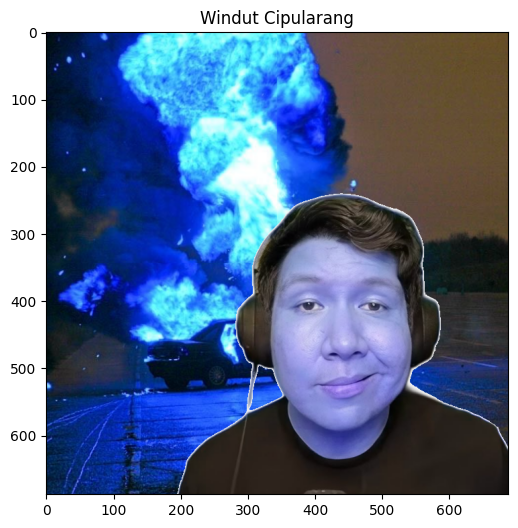

In [131]:
windut_warna = cv2.imread('Assets/Windut.png')
bg_warna = citra_utuh[:, :, ::-1] 

tinggi_w, lebar_w, kanal_w = windut_warna.shape
tinggi_bg, lebar_bg, kanal_bg = bg_warna.shape

tinggi_min = min(tinggi_w, tinggi_bg)
lebar_min = min(lebar_w, lebar_bg)

windut_crop_warna = np.zeros((tinggi_min, lebar_min, 3), dtype=np.uint8)
bg_crop_warna = np.zeros((tinggi_min, lebar_min, 3), dtype=np.uint8)

for i in range(tinggi_min):
    for j in range(lebar_min):
        for k in range(3):
            windut_crop_warna[i, j, k] = windut_warna[i, j, k]
            bg_crop_warna[i, j, k] = bg_warna[i, j, k]

hasil_cipularang = np.zeros((tinggi_min, lebar_min, 3), dtype=np.uint8)

for i in range(tinggi_min):
    for j in range(lebar_min):
        b = windut_crop_warna[i, j, 0]
        g = windut_crop_warna[i, j, 1]
        r = windut_crop_warna[i, j, 2]
 
        if b > 245 and g > 245 and r > 245:
            for k in range(3):
                hasil_cipularang[i, j, k] = bg_crop_warna[i, j, k]
        else:
            for k in range(3):
                hasil_cipularang[i, j, k] = windut_crop_warna[i, j, k]

plt.figure(figsize=(6, 6))
plt.imshow(hasil_cipularang)
plt.title('Windut Cipularang')
plt.axis('on')
plt.show()

Hasil visualisasi menunjukkan keberhasilan penggabungan citra berwarna menggunakan teknik masking pada ruang warna RGB. Pengkondisian ambang batas nilai 245 untuk setiap kanal (R, G, B) secara efektif mengidentifikasi latar belakang putih citra asli untuk digantikan dengan citra ledakan. Munculnya efek warna biru pada objek dan ledakan disebabkan oleh perbedaan urutan kanal warna antara OpenCV (BGR) dan Matplotlib (RGB), namun secara teknis operasional, logika penggabungan matriks tiga dimensi telah berjalan dengan benar. Proses ini memvalidasi bahwa manipulasi piksel pada citra berwarna dapat dilakukan secara manual melalui perulangan kanal warna untuk menghasilkan komposisi visual yang utuh.

# Kesimpulan

Berdasarkan seluruh rangkaian percobaan yang telah dilakukan, berikut adalah kesimpulan mengenai hubungan antaroperasi pengolahan citra pada Modul 2:

1. Manipulasi Spasial dan Matriks (Slicing & Merging)
Operasi pemotongan (cropping) dan penggabungan kembali (merging) membuktikan bahwa citra digital merupakan sekumpulan matriks yang dapat dimanipulasi secara numerik. Hal ini memenuhi indikator ketercapaian CPMK dalam hal kemampuan mengimplementasikan konsep dasar representasi citra digital melalui teknik slicing NumPy tanpa merusak nilai informasi aslinya.

2. Transformasi Ruang Warna dan Efisiensi Komputasi
Proses konversi dari RGB ke grayscale menunjukkan hubungan antara kompleksitas data dengan efisiensi pengolahan. Dengan mereduksi tiga kanal menjadi satu, beban komputasi menjadi lebih ringan untuk tahap analisis selanjutnya. Ini relevan dengan CPMK mengenai pemahaman transformasi ruang warna sebagai langkah pra-pemrosesan yang krusial dalam sistem visi komputer.

3. Peningkatan Kualitas Citra (Ekualisasi & Spesifikasi)
Ekualisasi histogram menunjukkan hubungan antara distribusi frekuensi piksel dengan kontras visual, sementara spesifikasi histogram membuktikan bahwa kita dapat mengontrol kualitas citra secara presisi berdasarkan referensi eksternal. Keberhasilan ini mencerminkan ketercapaian CPMK dalam menguasai teknik perbaikan kualitas citra (image enhancement) baik secara global maupun terarah menggunakan pendekatan stokastik (CDF).

4. Segmentasi dan Komposisi Citra (Masking & Thresholding)
Teknik masking melalui thresholding manual (baik pada citra grayscale maupun RGB) menunjukkan hubungan antara nilai intensitas piksel dengan pemisahan objek (foreground) dan latar belakang (background). Kemampuan menggabungkan dua citra berbeda secara logis dan matematis ini memenuhi target CPMK terkait penerapan algoritma dasar segmentasi citra untuk menghasilkan informasi visual yang baru dan informatif.